In [ ]:
import pandas as pd
import numpy as np
from scipy.spatial import KDTree

# Load the CSV file
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

# Extract latitude and longitude into a NumPy array
coords = data[['Latitude', 'Longitude']].to_numpy()

# Build the KD-Tree
tree = KDTree(coords)

# Query the KD-Tree for the nearest neighbor for each point
distances, indices = tree.query(coords, k=2)

# Store the results in the DataFrame
data['next_frame_id'] = data.iloc[indices[:, 1]]['Frame ID'].values
data['distance_to_next'] = distances[:, 1]

# Print the head of the DataFrame to check the updates
print(data.head())


   Frame ID Country Code  Longitude   Latitude  \
0     19519           PL  20.992104  52.243325   
1     61017           GB  -0.323732  51.492239   
2     37019           IT   9.194207  45.450716   
3     34898           PL  19.939118  50.044331   
4      7607           DE   6.961720  50.936171   

                               Time    Weather Condition Road Condition  \
0  2021-04-19 19:53:41.559140+00:00  partly-cloudy-night         normal   
1  2020-02-21 14:37:11.114462+00:00               cloudy         normal   
2  2020-07-22 10:24:50.112892+00:00            clear-day         normal   
3  2021-04-15 14:15:45.995595+00:00                  fog            wet   
4  2020-11-16 08:45:31.107847+00:00    partly-cloudy-day         normal   

  Time of Day Road Type  Number of Vehicles  Number of Lane Instances  \
0       night      city                  29                         3   
1         day   highway                  11                         0   
2         day      city      

In [ ]:
import pandas as pd
from geopy.distance import geodesic

# Load the CSV file
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

# Function to calculate distance between two coordinates
def calculate_distance(lat1, lon1, lat2, lon2):
    return geodesic((lat1, lon1), (lat2, lon2)).meters

# Find pairs of frames that are closest to each other
data['next_frame_id'] = None
data['distance_to_next'] = float('inf')

for i in range(len(data) - 1):
    lat1, lon1 = data.iloc[i]['Latitude'], data.iloc[i]['Longitude']
    for j in range(i + 1, len(data)):
        lat2, lon2 = data.iloc[j]['Latitude'], data.iloc[j]['Longitude']
        distance = calculate_distance(lat1, lon1, lat2, lon2)
        if distance < data.at[i, 'distance_to_next']:
            data.at[i, 'next_frame_id'] = data.at[j, 'Frame ID']
            data.at[i, 'distance_to_next'] = distance

# Print the head of the DataFrame to check the updates
print(data.head())


KeyboardInterrupt: 

In [ ]:
# Load the dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
data = pd.read_csv(file_path)

# Display basic information about the dataset
#print(data.info())
#print(data.describe())
#print(data.head())

# Remove non-relevant features
data = data.drop(columns=['Frame ID', 'Country Code', 'Longitude', 'Latitude', 'Time'])

# Convert categorical variables to one-hot encoding
data_encoded = pd.get_dummies(data, columns=['Weather Condition', 'Road Condition', 'Time of Day', 'Road Type'])

# Separate features (X) and target variable (y)
X = data_encoded.drop('Speed (kph)', axis=1)
y = data_encoded['Speed (kph)']

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train multiple models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_lr_pred = lr_model.predict(X_test)
lr_mse = mean_squared_error(y_test, y_lr_pred)

# Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)
y_rf_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, y_rf_pred)

# Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100)
gb_model.fit(X_train, y_train)
y_gb_pred = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, y_gb_pred)

# Support Vector Regressor
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)
y_svr_pred = svr_model.predict(X_test_scaled)
svr_mse = mean_squared_error(y_test, y_svr_pred)

# XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)
y_xgb_pred = xgb_model.predict(X_test)
xgb_mse = mean_squared_error(y_test, y_xgb_pred)

# Print MSE for all models
print(f"Linear Regression MSE: {lr_mse}")
print(f"Random Forest MSE: {rf_mse}")
print(f"Gradient Boosting MSE: {gb_mse}")
print(f"Support Vector Regressor MSE: {svr_mse}")
print(f"XGBoost MSE: {xgb_mse}")
print(f" ")
from sklearn.metrics import r2_score

# Calculate R-squared for each model
r2_lr = r2_score(y_test, y_lr_pred)
r2_rf = r2_score(y_test, y_rf_pred)
r2_gb = r2_score(y_test, y_gb_pred)
r2_svr = r2_score(y_test, y_svr_pred)
r2_xgb = r2_score(y_test, y_xgb_pred)

# Print R-squared for each model
print(f"Linear Regression R-squared: {r2_lr}")
print(f"Random Forest R-squared: {r2_rf}")
print(f"Gradient Boosting R-squared: {r2_gb}")
print(f"Support Vector Regressor R-squared: {r2_svr}")
print(f"XGBoost R-squared: {r2_xgb}")
print(f" ")
from sklearn.metrics import mean_absolute_error

# Calculate MAE for each model
mae_lr = mean_absolute_error(y_test, y_lr_pred)
mae_rf = mean_absolute_error(y_test, y_rf_pred)
mae_gb = mean_absolute_error(y_test, y_gb_pred)
mae_svr = mean_absolute_error(y_test, y_svr_pred)
mae_xgb = mean_absolute_error(y_test, y_xgb_pred)

# Print MAE for each model
print(f"Linear Regression MAE: {mae_lr}")
print(f"Random Forest MAE: {mae_rf}")
print(f"Gradient Boosting MAE: {mae_gb}")
print(f"Support Vector Regressor MAE: {mae_svr}")
print(f"XGBoost MAE: {mae_xgb}")
print(f" ")
from sklearn.metrics import explained_variance_score

# Calculate Explained Variance Score for each model
evs_lr = explained_variance_score(y_test, y_lr_pred)
evs_rf = explained_variance_score(y_test, y_rf_pred)
evs_gb = explained_variance_score(y_test, y_gb_pred)
evs_svr = explained_variance_score(y_test, y_svr_pred)
evs_xgb = explained_variance_score(y_test, y_xgb_pred)

# Print Explained Variance Score for each model
print(f"Linear Regression Explained Variance Score: {evs_lr}")
print(f"Random Forest Explained Variance Score: {evs_rf}")
print(f"Gradient Boosting Explained Variance Score: {evs_gb}")
print(f"Support Vector Regressor Explained Variance Score: {evs_svr}")
print(f"XGBoost Explained Variance Score: {evs_xgb}")
print(f" ")
#from sklearn.metrics import mean_squared_log_error


import numpy as np

# Calculate RMSE for each model (requires numpy for square root)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_lr_pred))
rmse_rf = np.sqrt(mean_squared_error(y_test, y_rf_pred))
rmse_gb = np.sqrt(mean_squared_error(y_test, y_gb_pred))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_svr_pred))
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_xgb_pred))

# Print RMSE for each model
print(f"Linear Regression RMSE: {rmse_lr}")
print(f"Random Forest RMSE: {rmse_rf}")
print(f"Gradient Boosting RMSE: {rmse_gb}")
print(f"Support Vector Regressor RMSE: {rmse_svr}")
print(f"XGBoost RMSE: {rmse_xgb}")






Linear Regression MSE: 306.48146636034426
Random Forest MSE: 278.9937189686891
Gradient Boosting MSE: 265.4883064040644
Support Vector Regressor MSE: 274.3721645080212
XGBoost MSE: 255.03456118712853
Linear Regression R-squared: 0.6302809649979384
Random Forest R-squared: 0.6634403712116712
Gradient Boosting R-squared: 0.6797324105313574
Support Vector Regressor R-squared: 0.6690155098185802
XGBoost R-squared: 0.6923431195561528
Linear Regression MAE: 13.628489230333853
Random Forest MAE: 12.885075788965274
Gradient Boosting MAE: 12.684925406973363
Support Vector Regressor MAE: 12.668742933556718
XGBoost MAE: 12.35132608790354
Linear Regression Explained Variance Score: 0.6302855608208606
Random Forest Explained Variance Score: 0.6634784604969423
Gradient Boosting Explained Variance Score: 0.6797328587368882
Support Vector Regressor Explained Variance Score: 0.6704149003821298
XGBoost Explained Variance Score: 0.6923439672576911
Linear Regression RMSE: 17.5066120754515
Random Forest RM

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
data = pd.read_csv(file_path)

# Display basic information about the dataset
# print(data.info())
# print(data.describe())
# print(data.head())

# Remove non-relevant features
data = data.drop(columns=['Frame ID', 'Country Code', 'Longitude', 'Latitude', 'Time'])

# Convert categorical variables to one-hot encoding
data_encoded = pd.get_dummies(data, columns=['Weather Condition', 'Road Condition', 'Time of Day', 'Road Type'])

# Separate features (X) and target variable (y)
X = data_encoded.drop('Speed (kph)', axis=1)
y = data_encoded['Speed (kph)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# # Initialize and train multiple models
# # Linear Regression
# lr_model = LinearRegression()
# lr_model.fit(X_train, y_train)
# y_lr_pred = lr_model.predict(X_test)

# # Random Forest Regressor
# rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
# rf_model.fit(X_train, y_train)
# y_rf_pred = rf_model.predict(X_test)

# # Gradient Boosting Regressor
# gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100)
# gb_model.fit(X_train, y_train)
# y_gb_pred = gb_model.predict(X_test)

# # Support Vector Regressor
# svr_model = SVR(kernel='rbf')
# svr_model.fit(X_train_scaled, y_train)
# y_svr_pred = svr_model.predict(X_test_scaled)

# # XGBoost Regressor
# xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100)
# xgb_model.fit(X_train, y_train)
# y_xgb_pred = xgb_model.predict(X_test)

# # Print MSE for all models
# models = {
#     'Linear Regression': lr_model,
#     'Random Forest': rf_model,
#     'Gradient Boosting': gb_model,
#     'Support Vector Regressor': svr_model,
#     'XGBoost': xgb_model
# }

# for name, model in models.items():
#     y_pred = model.predict(X_test)
#     mse = mean_squared_error(y_test, y_pred)
#     r2 = r2_score(y_test, y_pred)
#     mae = mean_absolute_error(y_test, y_pred)
#     evs = explained_variance_score(y_test, y_pred)
#     rmse = np.sqrt(mse)

#     print(f"{name}:")
#     print(f"  MSE: {mse}")
#     print(f"  R-squared: {r2}")
#     print(f"  MAE: {mae}")
#     print(f"  Explained Variance Score: {evs}")
#     print(f"  RMSE: {rmse}")
#     print()

# Neural Network (LSTM) Model
# Reshape input data for LSTM
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Ensure data types are float32
X_train_lstm = X_train_lstm.astype('float32')
X_test_lstm = X_test_lstm.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Initialize LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(1, X_train.shape[1])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train LSTM model
history = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
                         validation_data=(X_test_lstm, y_test), callbacks=[early_stop], verbose=1)

# Predictions using LSTM model
y_lstm_pred = model_lstm.predict(X_test_lstm).flatten()

# Evaluate LSTM model
mse_lstm = mean_squared_error(y_test, y_lstm_pred)
r2_lstm = r2_score(y_test, y_lstm_pred)
mae_lstm = mean_absolute_error(y_test, y_lstm_pred)
evs_lstm = explained_variance_score(y_test, y_lstm_pred)
rmse_lstm = np.sqrt(mse_lstm)

print("LSTM Model:")
print(f"  MSE: {mse_lstm}")
print(f"  R-squared: {r2_lstm}")
print(f"  MAE: {mae_lstm}")
print(f"  Explained Variance Score: {evs_lstm}")
print(f"  RMSE: {rmse_lstm}")


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 1468.8650 - val_loss: 503.1922
Epoch 2/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 417.5743 - val_loss: 299.8740
Epoch 3/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - loss: 291.0722 - val_loss: 277.8166
Epoch 4/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 271.9112 - val_loss: 270.9183
Epoch 5/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 267.0728 - val_loss: 267.3751
Epoch 6/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 263.0368 - val_loss: 264.5863
Epoch 7/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 261.9387 - val_loss: 262.6862
Epoch 8/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 260.8028 - val_loss: 262.1988
Epoch 9/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - loss: 256.4706 - val_loss: 262.0392
Epoch 10/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - loss: 256.5822 - val_loss: 260.1779
Epoch 11/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 256.7

In [ ]:
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Define the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(1, X_train.shape[1]), return_sequences=True))  # Example of adding more LSTM layers
model_lstm.add(Dropout(0.2))  # Example of dropout regularization
model_lstm.add(LSTM(50))  # Another LSTM layer
model_lstm.add(Dense(1))  # Output layer

# Compile the model
optimizer = Adam(learning_rate=0.001)  # Example of setting learning rate
model_lstm.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'mse'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train the LSTM model
history = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
                         validation_data=(X_test_lstm, y_test), callbacks=[early_stop], verbose=1)

# Evaluate the LSTM model
loss, mae, mse = model_lstm.evaluate(X_test_lstm, y_test, verbose=0)
print(f"LSTM Model Evaluation:")
print(f"  Loss: {loss}")
print(f"  MAE: {mae}")
print(f"  MSE: {mse}")

# Predictions using LSTM model
y_lstm_pred = model_lstm.predict(X_test_lstm).flatten()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - loss: 1399.2279 - mae: 27.8064 - mse: 1399.2279 - val_loss: 526.6605 - val_mae: 17.0607 - val_mse: 526.6605
Epoch 2/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 430.6789 - mae: 15.5691 - mse: 430.6789 - val_loss: 288.0687 - val_mae: 13.2128 - val_mse: 288.0687
Epoch 3/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 284.6381 - mae: 13.1734 - mse: 284.6381 - val_loss: 271.1231 - val_mae: 12.8984 - val_mse: 271.1231
Epoch 4/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 271.6831 - mae: 12.8817 - mse: 271.6831 - val_loss: 265.6790 - val_mae: 12.6470 - val_mse: 265.6790
Epoch 5/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 265.8423 - mae: 12.7129 - mse: 265.8423 - val_loss: 263.2767 - val_mae: 12.5827 - val_mse: 263.2767
Epoch 6/50
2379/2379 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 263.8624 - mae: 12.6501 - mse: 263.8624 - val_loss: 262.3468 - val_mae: 12.5787 - val_mse: 262.3468
Epoch 7/50
2379/2379

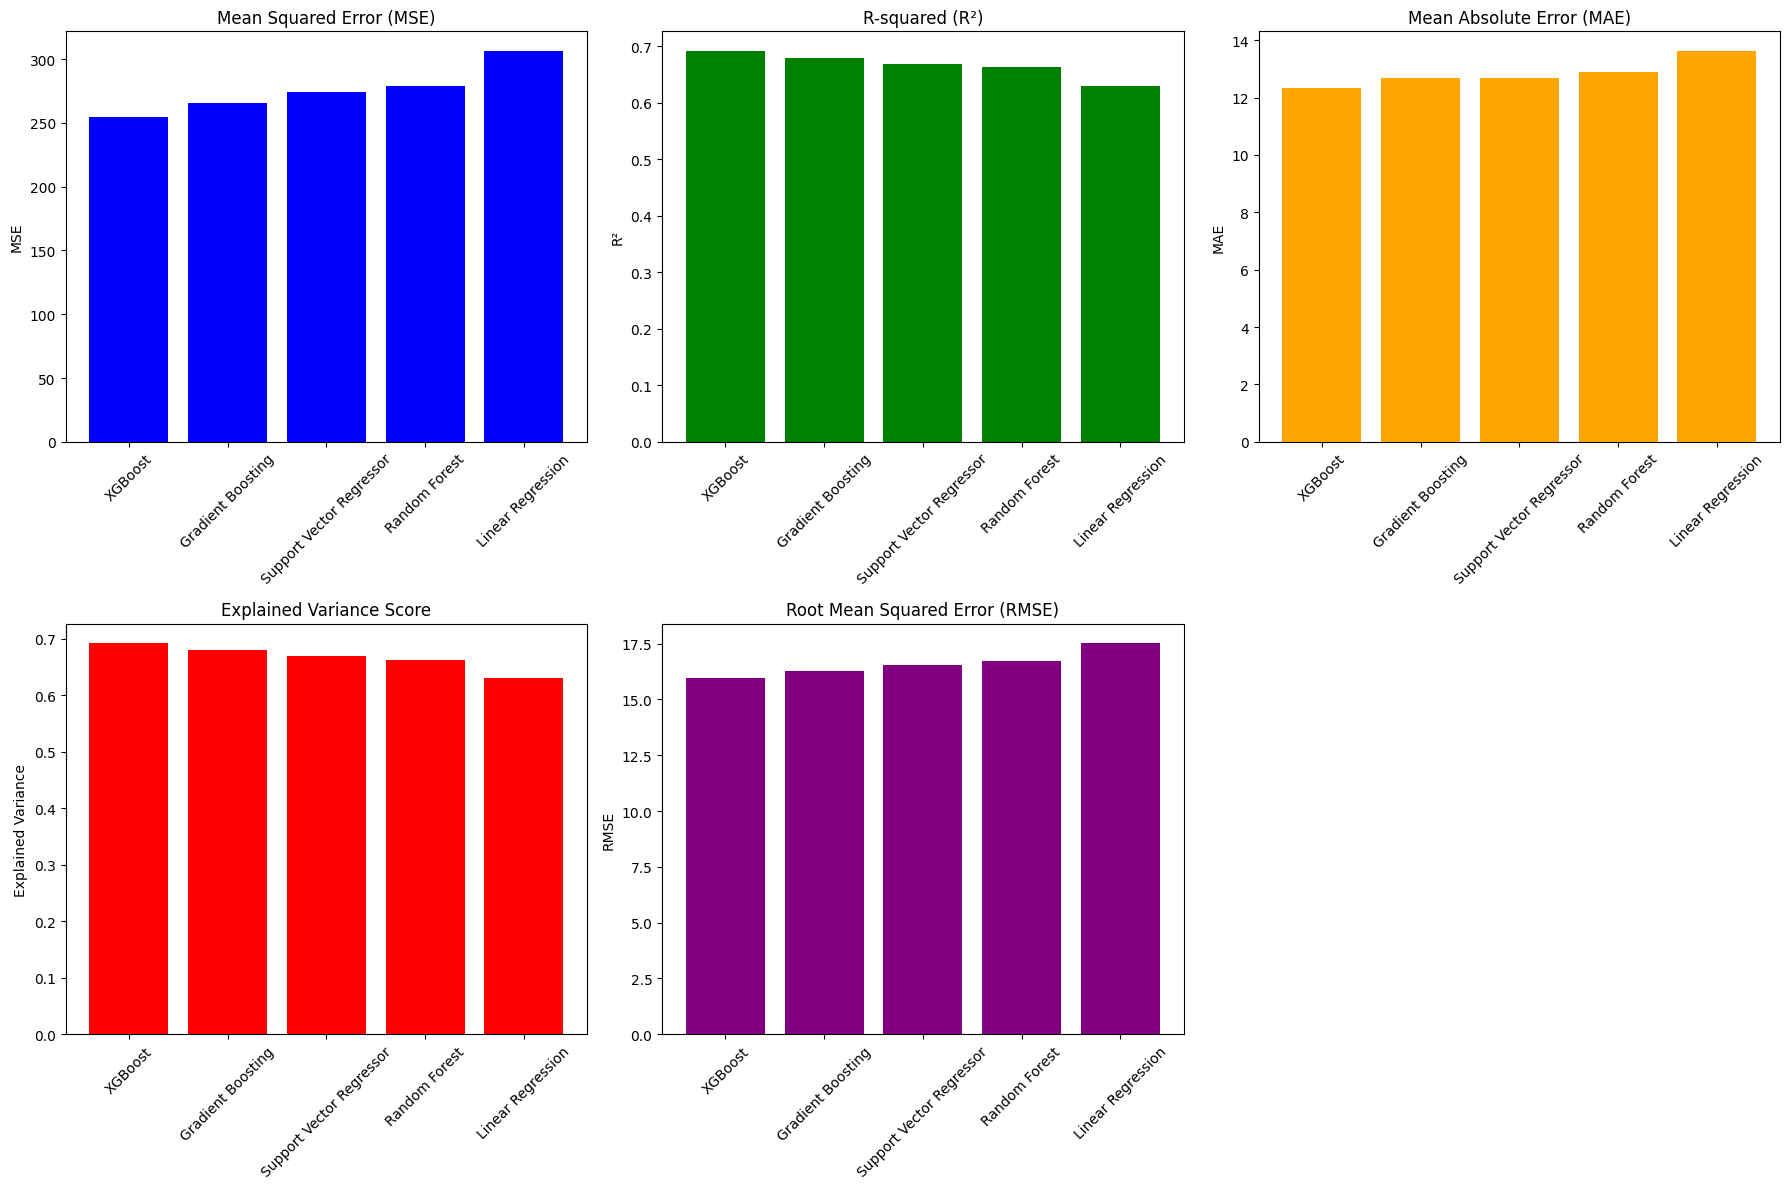

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'Support Vector Regressor', 'XGBoost']
mse_values = [306.48, 278.99, 265.49, 274.37, 255.03]
r2_values = [0.630, 0.663, 0.680, 0.669, 0.692]
mae_values = [13.63, 12.89, 12.68, 12.67, 12.35]
evs_values = [0.630, 0.663, 0.680, 0.670, 0.692]
rmse_values = [17.51, 16.70, 16.29, 16.56, 15.97]

# Sorting models based on MSE (best to worst)
sorted_indices = np.argsort(mse_values)
models_sorted = [models[i] for i in sorted_indices]
mse_values_sorted = [mse_values[i] for i in sorted_indices]
r2_values_sorted = [r2_values[i] for i in sorted_indices]
mae_values_sorted = [mae_values[i] for i in sorted_indices]
evs_values_sorted = [evs_values[i] for i in sorted_indices]
rmse_values_sorted = [rmse_values[i] for i in sorted_indices]

# Plotting
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Mean Squared Error (MSE)
axs[0, 0].bar(models_sorted, mse_values_sorted, color='blue')
axs[0, 0].set_title('Mean Squared Error (MSE)')
axs[0, 0].set_ylabel('MSE')
axs[0, 0].tick_params(axis='x', rotation=45)

# R-squared (R²)
axs[0, 1].bar(models_sorted, r2_values_sorted, color='green')
axs[0, 1].set_title('R-squared (R²)')
axs[0, 1].set_ylabel('R²')
axs[0, 1].tick_params(axis='x', rotation=45)

# Mean Absolute Error (MAE)
axs[0, 2].bar(models_sorted, mae_values_sorted, color='orange')
axs[0, 2].set_title('Mean Absolute Error (MAE)')
axs[0, 2].set_ylabel('MAE')
axs[0, 2].tick_params(axis='x', rotation=45)

# Explained Variance Score
axs[1, 0].bar(models_sorted, evs_values_sorted, color='red')
axs[1, 0].set_title('Explained Variance Score')
axs[1, 0].set_ylabel('Explained Variance')
axs[1, 0].tick_params(axis='x', rotation=45)

# Root Mean Squared Error (RMSE)
axs[1, 1].bar(models_sorted, rmse_values_sorted, color='purple')
axs[1, 1].set_title('Root Mean Squared Error (RMSE)')
axs[1, 1].set_ylabel('RMSE')
axs[1, 1].tick_params(axis='x', rotation=45)

# Remove the empty subplot in the second row, second column
fig.delaxes(axs[1, 2])

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor  # Example, use your trained model
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Assuming you have loaded and preprocessed your data
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
data = pd.read_csv(file_path)

# Drop non-relevant features and encode categorical variables if needed
data = data.drop(columns=['Frame ID', 'Country Code', 'Longitude', 'Latitude', 'Time'])
data_encoded = pd.get_dummies(data, columns=['Weather Condition', 'Road Condition', 'Time of Day', 'Road Type'])

# Separate features (X) and target variable (y)
X = data_encoded.drop('Speed (kph)', axis=1)
y = data_encoded['Speed (kph)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train your model (example with RandomForestRegressor)
model = RandomForestRegressor(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

# Evaluate the model (example with MSE)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 278.9937189686891


In [ ]:
def recommend_speed(model, current_speed, weather_condition, other_features):
    # Prepare the features consistently
    features = {
        'Speed (kph)': [current_speed],  # Use Speed (kph) from the dataset
        'Weather Condition': [weather_condition],
        **other_features
    }

    # Create a DataFrame from the features
    features_df = pd.DataFrame(features)

    # Encode categorical variables if necessary
    features_encoded = pd.get_dummies(features_df, columns=['Weather Condition'])

    # Predict the optimal speed
    predicted_speed = model.predict(features_encoded)

    # Determine recommendation based on predicted speed
    if predicted_speed > current_speed:
        recommendation = f"Increase speed to {predicted_speed[0]} km/h"
    elif predicted_speed < current_speed:
        recommendation = f"Reduce speed to {predicted_speed[0]} km/h"
    else:
        recommendation = f"Maintain current speed of {current_speed} km/h"

    return recommendation

# Example usage:
current_speed = 60  # Example current speed
weather_condition = 'Rainy'  # Example weather condition
other_features = {
    'Number of Lane Instances': 2,
    'Number of Pedestrians': 0,
    'Number of Traffic Lights': 1,
    'Number of Traffic Signs': 3,
    'Number of Vehicles': 5
}

recommendation = recommend_speed(model, current_speed, weather_condition, other_features)
print(recommendation)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Speed (kph)
- Weather Condition_Rainy
Feature names seen at fit time, yet now missing:
- Road Condition_normal
- Road Condition_snow
- Road Condition_wet
- Road Type_arterial-rural
- Road Type_arterial-urban
- ...


In [ ]:
import pandas as pd

# Load the dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
data = pd.read_csv(file_path)

# Display basic information about the dataset
# print(data.info())
# print(data.describe())
# print(data.head())
#print(data['Country Code'].unique())  # List all unique country codes

# Get the count of instances per country code
country_code_counts = data['Country Code'].value_counts()

print(country_code_counts)



Country Code
PL    29086
DE    23917
SE    16879
IT    11169
FR     7716
NO     1756
HU     1502
GB      875
IE      709
CZ      490
NL      464
LU      367
FI      129
SK       93
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Extract unique country codes
unique_country_codes = data['Country Code'].unique()

# Function to prepare data, train and evaluate models
def prepare_and_evaluate(data, country_code):
    # Filter data for the given country code
    country_data = data[data['Country Code'] == country_code]

    # Remove non-relevant features
    country_data = country_data.drop(columns=['Frame ID', 'Country Code', 'Longitude', 'Latitude', 'Time'])

    # Convert categorical variables to one-hot encoding
    data_encoded = pd.get_dummies(country_data, columns=['Weather Condition', 'Road Condition', 'Time of Day', 'Road Type'])

    # Separate features (X) and target variable (y)
    X = data_encoded.drop('Speed (kph)', axis=1)
    y = data_encoded['Speed (kph)']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Models dictionary
    models = {}

    # Random Forest Regressor
    rf_model = RandomForestRegressor(random_state=42, n_estimators=100)
    rf_model.fit(X_train, y_train)
    models['Random Forest'] = rf_model

    # XGBoost Regressor
    xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100)
    xgb_model.fit(X_train, y_train)
    models['XGBoost'] = xgb_model

    # Neural Network (LSTM) Model
    # Reshape input data for LSTM
    X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

    # Ensure data types are float32
    X_train_lstm = X_train_lstm.astype('float32')
    X_test_lstm = X_test_lstm.astype('float32')
    y_train = y_train.astype('float32')
    y_test = y_test.astype('float32')

    # Initialize LSTM model
    model_lstm = Sequential()
    model_lstm.add(LSTM(50, input_shape=(1, X_train.shape[1])))
    model_lstm.add(Dense(1))
    model_lstm.compile(optimizer='adam', loss='mse')

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(monitor='val_loss', patience=5)

    # Train LSTM model
    model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
                   validation_data=(X_test_lstm, y_test), callbacks=[early_stop], verbose=0)

    models['LSTM'] = model_lstm

    # Evaluate all models
    results = {}
    for name, model in models.items():
        if name == 'LSTM':
            y_pred = model.predict(X_test_lstm).flatten()
        else:
            y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        evs = explained_variance_score(y_test, y_pred)
        rmse = np.sqrt(mse)

        results[name] = {
            'MSE': mse,
            'R-squared': r2,
            'MAE': mae,
            'Explained Variance Score': evs,
            'RMSE': rmse
        }

    return results

# Dictionary to hold evaluation results for the subset of countries
evaluation_results_subset = {}

# Subset of country codes for evaluation (first 5 unique country codes)
subset_country_codes = unique_country_codes[:5]

# Evaluate models for the subset of countries
for country_code in subset_country_codes:
    evaluation_results_subset[country_code] = prepare_and_evaluate(data, country_code)

evaluation_results_subset


3/3 [==============================] - 1s 6ms/step


1/1 [==============================] - 0s 405ms/step


{'PL': {'Random Forest': {'MSE': 249.64195156871435,
   'R-squared': 0.40485568705094077,
   'MAE': 12.413224806419962,
   'Explained Variance Score': 0.40490129602585456,
   'RMSE': 15.800061758382919},
  'XGBoost': {'MSE': 242.73949,
   'R-squared': 0.42131109253209087,
   'MAE': 12.219429,
   'Explained Variance Score': 0.42131900787353516,
   'RMSE': 15.580099},
  'LSTM': {'MSE': 235.27054,
   'R-squared': 0.43911700677923315,
   'MAE': 12.077035,
   'Explained Variance Score': 0.4391447901725769,
   'RMSE': 15.3385315}},
 'GB': {'Random Forest': {'MSE': 426.988238046364,
   'R-squared': 0.5850588294752179,
   'MAE': 15.891375610659004,
   'Explained Variance Score': 0.5851577432134487,
   'RMSE': 20.663693717396317},
  'XGBoost': {'MSE': 650.3143,
   'R-squared': 0.36803366413046923,
   'MAE': 19.080294,
   'Explained Variance Score': 0.3682907819747925,
   'RMSE': 25.50126},
  'LSTM': {'MSE': 1167.0168,
   'R-squared': -0.13409050854224858,
   'MAE': 27.439917,
   'Explained Vari

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, explained_variance_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Load the dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/data.csv"
data = pd.read_csv(file_path)

# Filter data for country code 'PL'
country_data = data[data['Country Code'] == 'PL']

# Remove non-relevant features
country_data = country_data.drop(columns=['Frame ID', 'Country Code', 'Longitude', 'Latitude', 'Time'])

# Convert categorical variables to one-hot encoding
data_encoded = pd.get_dummies(country_data, columns=['Weather Condition', 'Road Condition', 'Time of Day', 'Road Type'])

# Separate features (X) and target variable (y)
X = data_encoded.drop('Speed (kph)', axis=1)
y = data_encoded['Speed (kph)']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=100),
    'Support Vector Regressor': SVR(kernel='rbf'),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_estimators=100)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    if name == 'Support Vector Regressor':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    evs = explained_variance_score(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {
        'MSE': mse,
        'R-squared': r2,
        'MAE': mae,
        'Explained Variance Score': evs,
        'RMSE': rmse
    }

# Prepare data for LSTM model
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

# Ensure data types are float32
X_train_lstm = X_train_lstm.astype('float32')
X_test_lstm = X_test_lstm.astype('float32')
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

# Initialize LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(50, input_shape=(1, X_train.shape[1])))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mse')

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Train LSTM model
history = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
                         validation_data=(X_test_lstm, y_test), callbacks=[early_stop], verbose=1)

# Predictions using LSTM model
y_lstm_pred = model_lstm.predict(X_test_lstm).flatten()

# Evaluate LSTM model
mse_lstm = mean_squared_error(y_test, y_lstm_pred)
r2_lstm = r2_score(y_test, y_lstm_pred)
mae_lstm = mean_absolute_error(y_test, y_lstm_pred)
evs_lstm = explained_variance_score(y_test, y_lstm_pred)
rmse_lstm = np.sqrt(mse_lstm)

# Store LSTM results
results['LSTM'] = {
    'MSE': mse_lstm,
    'R-squared': r2_lstm,
    'MAE': mae_lstm,
    'Explained Variance Score': evs_lstm,
    'RMSE': rmse_lstm
}

# Print the results
for model_name, metrics in results.items():
    print(f"{model_name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value}")
    print()


Epoch 1/50
728/728 [==============================] - 7s 7ms/step - loss: 900.2886 - val_loss: 480.7072
Epoch 2/50
728/728 [==============================] - 3s 4ms/step - loss: 453.1495 - val_loss: 408.7211
Epoch 3/50
728/728 [==============================] - 3s 4ms/step - loss: 397.2950 - val_loss: 352.2940
Epoch 4/50
728/728 [==============================] - 3s 4ms/step - loss: 346.7433 - val_loss: 316.7444
Epoch 5/50
728/728 [==============================] - 3s 4ms/step - loss: 319.9817 - val_loss: 300.4385
Epoch 6/50
728/728 [==============================] - 4s 6ms/step - loss: 304.7861 - val_loss: 288.0109
Epoch 7/50
728/728 [==============================] - 3s 4ms/step - loss: 293.6916 - val_loss: 279.9869
Epoch 8/50
728/728 [==============================] - 3s 4ms/step - loss: 286.1482 - val_loss: 272.5950
Epoch 9/50
728/728 [==============================] - 3s 4ms/step - loss: 280.0516 - val_loss: 267.4564
Epoch 10/50
728/728 [==============================] - 3s 5ms/st

In [ ]:
# Install folium
!pip install folium

import pandas as pd
import folium
from folium.plugins import MarkerCluster

# Load the dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/ZOD-CSV-Datasets/data.csv"
data = pd.read_csv(file_path)

# Filter data for specific country codes
country_codes = ['DE', 'PL', 'IT', 'SE', 'FR']
country_data = data[data['Country Code'].isin(country_codes)]

# Get the mean latitude and longitude for initial map location
mean_lat = country_data['Latitude'].mean()
mean_lon = country_data['Longitude'].mean()

# Create a map centered at the mean latitude and longitude
map_center = [mean_lat, mean_lon]
m = folium.Map(location=map_center, zoom_start=6)

# Add points to the map
marker_cluster = MarkerCluster().add_to(m)
for idx, row in country_data.iterrows():
    folium.Marker(location=[row['Latitude'], row['Longitude']], popup=f"Speed: {row['Speed (kph)']} kph").add_to(marker_cluster)

# Display the map
m
